14/03 : notebook V2 pour optimiser le nettoyage du dataset

1) Imports

In [5]:
import tensorflow as tf
from tensorflow.keras import Sequential, Input, layers, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pandas as pd

2) Nettoyage du dataset --> de quoi est-il composé exactement ?

In [2]:
path_train = "../data/out/train"

print("--- COMPTAGE DES OEUVRES PAR CLASSE ---")

for dossier in sorted(os.listdir(path_train)):
    chemin_complet = os.path.join(path_train, dossier)
    if os.path.isdir(chemin_complet):
        nb_images = len(os.listdir(chemin_complet))
        print(f"{dossier} : {nb_images} images")

--- COMPTAGE DES OEUVRES PAR CLASSE ---
Abstract_Expressionism : 2075 images
Art_Nouveau_Modern : 3301 images
Baroque : 3376 images
Expressionism : 5064 images
Impressionism : 10135 images
Northern_Renaissance : 2041 images
Post_Impressionism : 5039 images
Realism : 8427 images
Romanticism : 5491 images
Symbolism : 3525 images


Stratégie : suite à l'analyse du dataset et aux divers conseils, nous décidons de partir sur 10 courants artistiques avec un nombre d'images maximal ET homogène (2075 images pour chaque courant). Nous devons donc enlever les images superflues et créer un dataset bien mélangé, pour éviter que le programme apprenne les courants à la suite des autres et ne soit pas capable

In [12]:
# Test de diagnostic
test_row = df[df['genre_count'] > 1].iloc[0]
print(f"DEBUG - Genre : '{test_row['genre']}'")
print(f"DEBUG - Filename : '{test_row['filename']}'")
print(f"DEBUG - Chemin complet construit : {os.path.join(base_dir, str(test_row['genre']), str(test_row['filename']))}")

DEBUG - Genre : '['Abstract Expressionism', 'Abstract Expressionism']'
DEBUG - Filename : 'Abstract_Expressionism/brice-marden_untitled-press-series-1972-1.jpg'
DEBUG - Chemin complet construit : ../data/in/kaggle-wikiart/['Abstract Expressionism', 'Abstract Expressionism']/Abstract_Expressionism/brice-marden_untitled-press-series-1972-1.jpg


In [13]:
base_dir = os.path.join("..", "data", "in", "kaggle-wikiart")
csv_path = os.path.join(base_dir, "classes.csv")

df = pd.read_csv(csv_path)

# 1. Identification
mask_to_delete = df['genre_count'] > 1
df_to_delete = df[mask_to_delete]

deleted_files = 0
missing_files = 0

print(f"--- Nettoyage Physique (Tentative 2) ---")

for index, row in df_to_delete.iterrows():
    # Correction majeure : on utilise directement base_dir + filename 
    # car 'filename' contient déjà 'Abstract_Expressionism/image.jpg'
    file_path = os.path.join(base_dir, str(row['filename']))
    
    if os.path.exists(file_path):
        os.remove(file_path)
        deleted_files += 1
    else:
        # On affiche le premier échec pour vérifier si besoin
        if missing_files == 0:
            print(f"DEBUG - Exemple de chemin tenté : {file_path}")
        missing_files += 1

print(f"\nRésultat :")
print(f"Supprimés : {deleted_files}")
print(f"Introuvables : {missing_files}")

# 2. Sauvegarde du CSV propre
if deleted_files > 0 or to_delete_count == missing_files: 
    df_clean = df[df['genre_count'] == 1].copy()
    output_csv = os.path.join(base_dir, "classes_filtered_v1.csv")
    df_clean.to_csv(output_csv, index=False)
    print(f"\n✅ État Final : {len(df_clean)} lignes conservées.")

--- Nettoyage Physique (Tentative 2) ---
DEBUG - Exemple de chemin tenté : ../data/in/kaggle-wikiart/Cubism/roger-bissiã¨re_paysage-1931.jpg

Résultat :
Supprimés : 1386
Introuvables : 14

✅ État Final : 78642 lignes conservées.


In [16]:
# on passe à la suppression des codes pHash similaires, on remarque qu'on reprend nouveau fichier classes_filtered_V1 pour inclure
from PIL import Image
import imagehash

# 1. Chemins
base_dir = os.path.join("..", "data", "in", "kaggle-wikiart")
csv_path = os.path.join(base_dir, "classes_filtered_v1.csv")
df = pd.read_csv(csv_path)

# 2. Initialisation
hashes = {}
duplicates_to_delete = []
total = len(df)

print(f"Lancement du scan pHash sur {total} images...")
print("Un point de situation s'affichera toutes les 5000 images.")

# 3. Boucle de calcul
for i, (index, row) in enumerate(df.iterrows()):
    file_path = os.path.join(base_dir, str(row['filename']))
    
    if os.path.exists(file_path):
        try:
            with Image.open(file_path) as img:
                # Calcul du pHash
                h = str(imagehash.phash(img))
                
                if h in hashes:
                    duplicates_to_delete.append(index)
                else:
                    hashes[h] = index
        except Exception as e:
            # On ignore les fichiers corrompus pour l'instant
            pass

    # Petit feedback manuel
    if (i + 1) % 5000 == 0:
        print(f"Progression : {i + 1} / {total} images traitées...")

# 4. Nettoyage
print(f"\nScan terminé. Doublons trouvés : {len(duplicates_to_delete)}")

deleted_count = 0
for idx in duplicates_to_delete:
    file_path = os.path.join(base_dir, str(df.loc[idx, 'filename']))
    if os.path.exists(file_path):
        os.remove(file_path)
        deleted_count += 1

# 5. Mise à jour du CSV
df_clean_phash = df.drop(duplicates_to_delete)
output_csv = os.path.join(base_dir, "classes_filtered_v2.csv")
df_clean_phash.to_csv(output_csv, index=False)

print(f"\n✅ Terminé ! {deleted_count} fichiers supprimés physiquement.")
print(f"Nouveau fichier : {output_csv}")

Lancement du scan pHash sur 78642 images...
Un point de situation s'affichera toutes les 5000 images.
Progression : 5000 / 78642 images traitées...
Progression : 10000 / 78642 images traitées...
Progression : 15000 / 78642 images traitées...
Progression : 20000 / 78642 images traitées...
Progression : 25000 / 78642 images traitées...
Progression : 30000 / 78642 images traitées...
Progression : 35000 / 78642 images traitées...
Progression : 40000 / 78642 images traitées...
Progression : 45000 / 78642 images traitées...
Progression : 50000 / 78642 images traitées...
Progression : 55000 / 78642 images traitées...
Progression : 60000 / 78642 images traitées...
Progression : 65000 / 78642 images traitées...
Progression : 70000 / 78642 images traitées...
Progression : 75000 / 78642 images traitées...

Scan terminé. Doublons trouvés : 22

✅ Terminé ! 22 fichiers supprimés physiquement.
Nouveau fichier : ../data/in/kaggle-wikiart/classes_filtered_v2.csv


3) On élimine les ratios trop spécifiques
Rappel hypothèse 0.33<ratio>3

In [17]:
# 1. Chargement du CSV issu du pHash
base_dir = os.path.join("..", "data", "in", "kaggle-wikiart")
csv_path = os.path.join(base_dir, "classes_filtered_v2.csv")
df = pd.read_csv(csv_path)

initial_count = len(df)
to_keep = []
ratios_rejected = 0

print(f"Analyse des formats sur {initial_count} images...")

# 2. Boucle de vérification des dimensions
for index, row in df.iterrows():
    file_path = os.path.join(base_dir, str(row['filename']))
    
    if os.path.exists(file_path):
        try:
            # On utilise Image.open sans charger les pixels (très rapide)
            with Image.open(file_path) as img:
                width, height = img.size
                ratio = width / height
                
                # Critère : 0.33 < ratio < 3
                if 0.33 <= ratio <= 3.0:
                    to_keep.append(index)
                else:
                    # On supprime physiquement l'image hors-format
                    os.remove(file_path)
                    ratios_rejected += 1
        except:
            # Si image corrompue, on ne la garde pas
            pass

# 3. Création du DataFrame filtré
df_final_geometry = df.loc[to_keep].copy()

# 4. Sauvegarde finale de la phase de nettoyage
output_csv = os.path.join(base_dir, "classes_filtered_v3.csv")
df_final_geometry.to_csv(output_csv, index=False)

print(f"\n--- Bilan du filtrage géométrique ---")
print(f"Images supprimées (ratio extrême) : {ratios_rejected}")
print(f"Images conservées : {len(df_final_geometry)}")
print(f"Ratio de conservation : {(len(df_final_geometry)/initial_count)*100:.2f}%")

Analyse des formats sur 78620 images...

--- Bilan du filtrage géométrique ---
Images supprimées (ratio extrême) : 288
Images conservées : 77651
Ratio de conservation : 98.77%


Quels sont les 10 courants les plus important maintenant ?

In [20]:
# 1. On compte les occurrences de chaque genre
counts = df_final_geometry['genre'].value_counts()

# 3. Si tu veux juste voir les 10 premiers (ton futur dataset)
print("\n--- TOP 10 POTENTIEL ---")
print(counts.head(10))


--- TOP 10 POTENTIEL ---
genre
['Impressionism']             12463
['Realism']                   10509
['Romanticism']                6819
['Post Impressionism']         6262
['Expressionism']              6262
['Baroque']                    4183
['Art Nouveau Modern']         4092
['Symbolism']                  4046
['Abstract Expressionism']     2559
['Northern Renaissance']       2522
Name: count, dtype: int64


In [21]:
# 1. Charger l'original (AVANT) et utiliser ton DF actuel (APRÈS)
df_before = pd.read_csv(os.path.join("..", "data", "in", "kaggle-wikiart", "classes.csv"))
# On part du principe que df_final_geometry est ton DF de 77 651 lignes

# 2. Compter les occurrences par genre pour les deux
counts_before = df_before['genre'].value_counts()
counts_after = df_final_geometry['genre'].value_counts()

# 3. Créer un DataFrame de comparaison
comparison_df = pd.DataFrame({
    'Avant Cleanage': counts_before,
    'Après Cleanage': counts_after
}).fillna(0).astype(int) # fillna(0) au cas où un genre aurait disparu

# 4. Calculer la différence et le % de conservation
comparison_df['Différence'] = comparison_df['Après Cleanage'] - comparison_df['Avant Cleanage']
comparison_df['% Conservation'] = (comparison_df['Après Cleanage'] / comparison_df['Avant Cleanage'] * 100).round(2)

# 5. Trier par le nombre d'images final pour voir ton futur Top 10
comparison_df = comparison_df.sort_values(by='Après Cleanage', ascending=False)

print("--- COMPARAISON DE LA DISTRIBUTION DES CLASSES ---")
display(comparison_df.head(15))

--- COMPARAISON DE LA DISTRIBUTION DES CLASSES ---


,Avant Cleanage,Après Cleanage,Différence,% Conservation
genre,,,,
['Impressionism'],12847,12463,-384,97.01
['Realism'],10534,10509,-25,99.76
['Romanticism'],6896,6819,-77,98.88
['Post Impressionism'],6274,6262,-12,99.81
['Expressionism'],6280,6262,-18,99.71
['Baroque'],4202,4183,-19,99.55
['Art Nouveau Modern'],4155,4092,-63,98.48
['Symbolism'],4174,4046,-128,96.93
['Abstract Expressionism'],2574,2559,-15,99.42


On remarquera qu'entre le décompte initial et celui-ci, des courants comme le symbolisme ont un nombre d'oeuvres plus fort qu'au début. Il peut y avoir des fichiers fantomes, des problèmes de classificationa 
Besoin de spécifier ici

4) on choisit les 8 premiers courants à 2522 images, on va juste couper aléatoirement les courants Impressionism et Realism par 2 pour ne pas qu'ils monopolisent l'entraînement.

In [24]:
# 1. On "aplatit" la colonne genre : on prend le premier élément si c'est une liste
# ou on garde la valeur si c'est déjà du texte.
def clean_genre(x):
    if isinstance(x, list):
        return str(x[0])
    return str(x)

df_final_geometry['genre'] = df_final_geometry['genre'].apply(clean_genre)

# 2. Nettoyage des caractères résiduels (crochets, guillemets, espaces)
df_final_geometry['genre'] = (
    df_final_geometry['genre']
    .str.replace(r"[\[\]']", "", regex=True) # Enlève [ ] et '
    .str.strip()
)

# 3. On relance la sélection du Top 8 avec les noms propres
top_8_genres = df_final_geometry['genre'].value_counts().head(8).index.tolist()
genres_a_reduire = ['Impressionism', 'Realism']

frames = []

print("--- CONSTRUCTION DU DATASET SUR MESURE (V3) ---")

for genre in top_8_genres:
    df_genre = df_final_geometry[df_final_geometry['genre'] == genre]
    
    # Le test 'in' va maintenant fonctionner car 'genre' est une String propre !
    if genre in genres_a_reduire:
        n_to_keep = len(df_genre) // 2
        df_sampled = df_genre.sample(n=n_to_keep, random_state=42)
        print(f"✂️  {genre:25} : Réduit de moitié -> {len(df_sampled)} images")
    else:
        df_sampled = df_genre
        print(f"✅ {genre:25} : Conservation totale -> {len(df_sampled)} images")
    
    frames.append(df_sampled)

df_custom = pd.concat(frames).reset_index(drop=True)
print(f"\n🚀 Taille finale : {len(df_custom)} images.")

--- CONSTRUCTION DU DATASET SUR MESURE (V3) ---
✂️  Impressionism             : Réduit de moitié -> 6231 images
✂️  Realism                   : Réduit de moitié -> 5254 images
✅ Romanticism               : Conservation totale -> 6819 images
✅ Post Impressionism        : Conservation totale -> 6262 images
✅ Expressionism             : Conservation totale -> 6262 images
✅ Baroque                   : Conservation totale -> 4183 images
✅ Art Nouveau Modern        : Conservation totale -> 4092 images
✅ Symbolism                 : Conservation totale -> 4046 images

🚀 Taille finale : 43149 images.


6) On valide le cleanage du dataset, on utilisera df_custom maintenant, on peut en créer un csv = checkpoint

In [25]:
# On définit le chemin de sauvegarde
checkpoint_path = os.path.join("..", "data", "in", "kaggle-wikiart", "dataset_final_custom.csv")

# Sauvegarde du CSV
# index=False est important pour ne pas rajouter une colonne de numéros inutiles
df_custom.to_csv(checkpoint_path, index=False)

print(f"✅ CSV de contrôle créé avec succès !")
print(f"Chemin : {os.path.abspath(checkpoint_path)}")

# Petit rappel de la distribution pour la route
print("\nDistribution finale dans le CSV :")
print(df_custom['genre'].value_counts())

✅ CSV de contrôle créé avec succès !
Chemin : /home/emmanuelle/code/Lionel-Nokia/art-xplain/art-xplain/data/in/kaggle-wikiart/dataset_final_custom.csv

Distribution finale dans le CSV :
genre
Romanticism           6819
Post Impressionism    6262
Expressionism         6262
Impressionism         6231
Realism               5254
Baroque               4183
Art Nouveau Modern    4092
Symbolism             4046
Name: count, dtype: int64


7) On créé les nouveaux train, val

In [26]:
from sklearn.model_selection import train_test_split

# 1. On crée le premier split : on sépare 80% pour le Train
# Les 20% restants (temp) serviront pour Val et Test
df_train, df_temp = train_test_split(
    df_custom, 
    test_size=0.20,      # 20% pour Val + Test
    random_state=42,    # Pour que ton mélange soit le même si tu relances le code
    stratify=df_custom['genre'] # Garde les proportions de chaque courant
)

# 2. On divise les 20% restants en deux parts égales (10% Val, 10% Test)
df_val, df_test = train_test_split(
    df_temp, 
    test_size=0.50,      # On coupe les 20% en deux
    random_state=42, 
    stratify=df_temp['genre']
)

print(f"📊 Répartition finale :")
print(f"Train : {len(df_train)} images")
print(f"Val   : {len(df_val)} images")
print(f"Test  : {len(df_test)} images")

📊 Répartition finale :
Train : 34519 images
Val   : 4315 images
Test  : 4315 images


8) On retravaille train, val et test, pour qu'ils soient utilisables par le CNN

In [28]:
# 1. Définition des chemins (Vérifie bien que ces dossiers existent)
base_in = os.path.join("..", "data", "in", "kaggle-wikiart")
base_out = os.path.join("..", "data", "processed")

# Dictionnaire pour boucler sur tes DataFrames créés précédemment
data_splits = {
    'train': df_train,
    'val': df_val,
    'test': df_test
}

print("🚀 Début de la copie physique...")

for split_name, df_split in data_splits.items():
    success_count = 0
    error_count = 0
    
    for _, row in df_split.iterrows():
        # Chemin source : où est l'image actuellement
        # row['filename'] contient normalement 'Genre/image.jpg'
        src_path = os.path.join(base_in, row['filename'])
        
        # Chemin destination : data/processed/train/Genre/image.jpg
        dest_dir = os.path.join(base_out, split_name, row['genre'])
        os.makedirs(dest_dir, exist_ok=True)
        dest_path = os.path.join(dest_dir, os.path.basename(row['filename']))
        
        try:
            if os.path.exists(src_path):
                shutil.copy(src_path, dest_path)
                success_count += 1
            else:
                error_count += 1
        except Exception as e:
            error_count += 1

    print(f"--- Split {split_name.upper()} ---")
    print(f"✅ Copiés : {success_count}")
    print(f"❌ Introuvables/Erreurs : {error_count}")

print("\n✨ Vérification terminée. Regarde maintenant ton dossier 'processed' !")

🚀 Début de la copie physique...
--- Split TRAIN ---
✅ Copiés : 34519
❌ Introuvables/Erreurs : 0
--- Split VAL ---
✅ Copiés : 4315
❌ Introuvables/Erreurs : 0
--- Split TEST ---
✅ Copiés : 4315
❌ Introuvables/Erreurs : 0

✨ Vérification terminée. Regarde maintenant ton dossier 'processed' !


In [29]:
# Paramètres de base
IMG_SIZE = (224, 224) # Standard pour beaucoup de modèles
BATCH_SIZE = 32

# Chargement du dataset d'entraînement
train_ds = tf.keras.utils.image_dataset_from_directory(
    '../data/processed/train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical' # Important car tu as 8 classes
)

# Chargement du dataset de validation
val_ds = tf.keras.utils.image_dataset_from_directory(
    '../data/processed/val',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Récupérer les noms des classes (pour vérification)
class_names = train_ds.class_names
print(f"Classes détectées : {class_names}")

Found 34519 files belonging to 8 classes.


E0000 00:00:1773498283.610119  183864 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 4315 files belonging to 8 classes.
Classes détectées : ['Art Nouveau Modern', 'Baroque', 'Expressionism', 'Impressionism', 'Post Impressionism', 'Realism', 'Romanticism', 'Symbolism']


9) On instancie le modèle du CNN

In [31]:
model = Sequential([
    # Mise à l'échelle (Normalisation des pixels 0-255 -> 0-1)
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    
    # Premier bloc : détection des formes simples
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Deuxième bloc : motifs plus complexes
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Troisième bloc
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Classification finale
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Protection contre le sur-apprentissage
    layers.Dense(8, activation='softmax') # 8 neurones pour tes 8 courants
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/home/emmanuelle/.pyenv/versions/3.10.6/envs/art-xplain/lib/python3.10/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [32]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20, # On met 20, mais l'EarlyStop coupera sûrement avant
    callbacks=[early_stop]
)

Epoch 1/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 805s 744ms/step - accuracy: 0.2196 - loss: 1.9650 - val_accuracy: 0.2973 - val_loss: 1.8352
Epoch 2/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 913s 846ms/step - accuracy: 0.2962 - loss: 1.8122 - val_accuracy: 0.3217 - val_loss: 1.7142
Epoch 3/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 914s 846ms/step - accuracy: 0.3334 - loss: 1.7299 - val_accuracy: 0.3636 - val_loss: 1.6609
Epoch 4/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 899s 833ms/step - accuracy: 0.3652 - loss: 1.6501 - val_accuracy: 0.3724 - val_loss: 1.6361
Epoch 5/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 867s 803ms/step - accuracy: 0.3949 - loss: 1.5663 - val_accuracy: 0.3720 - val_loss: 1.6498
Epoch 6/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 865s 801ms/step - accuracy: 0.4334 - loss: 1.4551 - val_accuracy: 0.3710 - val_loss: 1.7387
Epoch 7/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 914s 847ms/step - accuracy: 0.4737 - loss: 1.3472 - val_accuracy: 0.3768 - val_loss: 1.7458


Observations avec les résultats : quels styles se ressemblent du point e vue de la machine ?


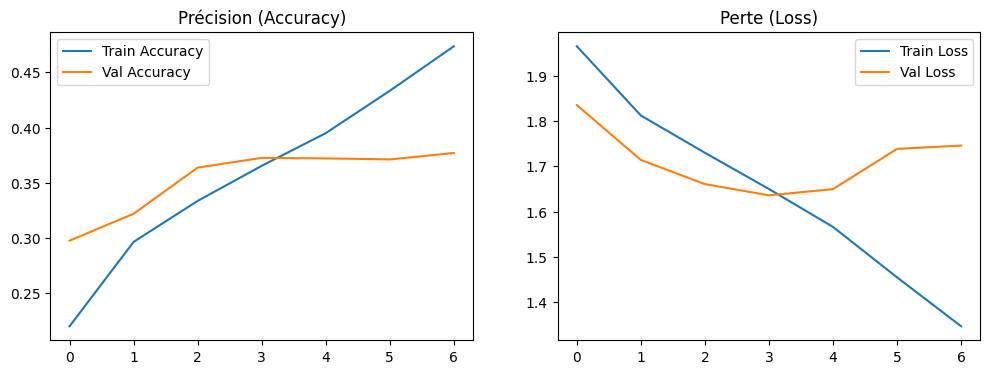

In [33]:
def plot_history(history):
    plt.figure(figsize=(12, 4))
    
    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Précision (Accuracy)')
    plt.legend()
    
    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Perte (Loss)')
    plt.legend()
    
    plt.show()

plot_history(history)

Matrice de confusion

In [36]:
# On définit le chemin vers ton dossier de test
test_dir = '../data/processed/test'

# On crée le dataset de test (exactement comme pour train et val)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    shuffle=False # TRÈS IMPORTANT : On ne mélange pas pour la matrice de confusion !
)

# On récupère les noms des classes pour être sûr qu'elles sont là
class_names = test_ds.class_names
print(f"✅ Dataset de test chargé avec {len(class_names)} classes.")

Found 4315 files belonging to 8 classes.
✅ Dataset de test chargé avec 8 classes.


⏳ Calcul des prédictions sur le set de Test (cela peut prendre 1-2 min)...


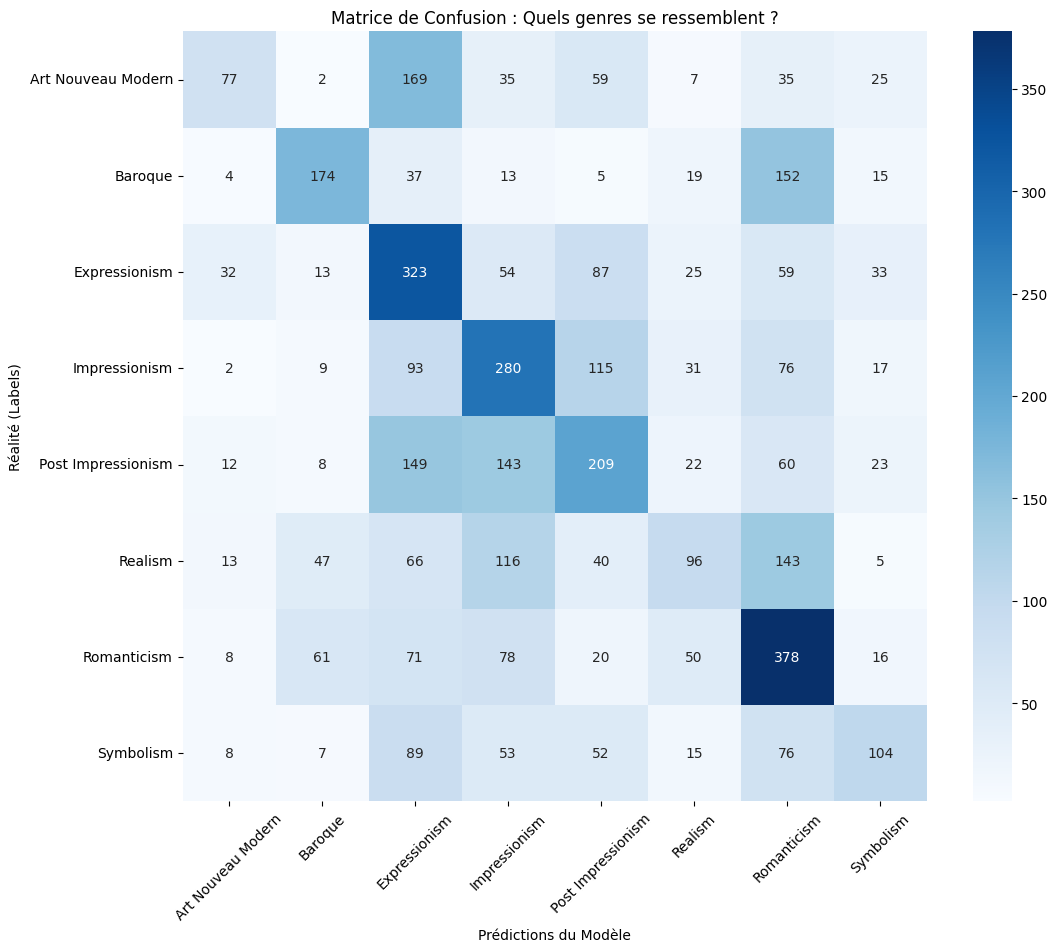

In [37]:
# On s'assure que class_names est bien défini (récupéré depuis le dataset)
class_names = train_ds.class_names 

y_true = []
y_pred = []

print("⏳ Calcul des prédictions sur le set de Test (cela peut prendre 1-2 min)...")

# Utilisation de test_ds (le set que le modèle n'a JAMAIS vu)
for images, labels in test_ds:
    preds = model.predict(images, verbose=0) # verbose=0 pour éviter de polluer l'écran
    
    # labels sont en categorical (one-hot), on prend l'index du max
    y_true.extend(np.argmax(labels, axis=1))
    # preds sont des probabilités, on prend l'index du max
    y_pred.extend(np.argmax(preds, axis=1))

# Création de la matrice
cm = confusion_matrix(y_true, y_pred)

# Affichage avec Seaborn pour que ce soit joli et lisible
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, 
            yticklabels=class_names)

plt.title('Matrice de Confusion : Quels genres se ressemblent ?')
plt.xlabel('Prédictions du Modèle')
plt.ylabel('Réalité (Labels)')
plt.xticks(rotation=45)
plt.show()

In [38]:
# Sauvegarde locale
model.save('mon_modele_wikiart_v1.h5')

print("💾 Modèle sauvegardé avec succès sous 'mon_modele_wikiart_v1.h5'")

💾 Modèle sauvegardé avec succès sous 'mon_modele_wikiart_v1.h5'
